In [1]:
import numpy as np
import anndata
import scanpy as sc
import pandas as pd

import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt

import harmonypy as hm
import os

In [2]:
# package versions
print(f"numpy=={np.__version__}")
print(f"anndata=={anndata.__version__}")
print(f"scanpy=={sc.__version__}")
print(f"pandas=={pd.__version__}")
print(f"seaborn=={sns.__version__}")
print(f"matplotlib=={matplotlib.__version__}")
print(f"matplotlib=={hm.__version__}")

numpy==1.26.4
anndata==0.12.1
scanpy==1.11.4
pandas==2.3.1
seaborn==0.13.2
matplotlib==3.10.5
matplotlib==0.2.0


In [3]:
path_data = "C:/Users/NORA/hlca_core.h5ad"
adata = anndata.read_h5ad(path_data, backed = 'r')
# subset smg
smg = adata[adata.obs["ann_level_3"] == 'Submucosal Secretory'].to_memory()

# results path
path_results = 'Result_plots'
if not os.path.exists(path_results):
    os.makedirs(path_results)

Define palettes, helper functions:

In [4]:
# cell type palette
type_palette = sns.color_palette(palette='tab20b')
type_palette[0], type_palette[1], type_palette[2], type_palette[3] = type_palette[0], type_palette[2], type_palette[16], type_palette[18]

# dataset palette
order = smg.obs["dataset"].value_counts().index.tolist()
smg.obs["dataset"] = pd.Categorical(smg.obs["dataset"], categories=order, ordered=True)

# donor palette
donor_palette = sns.color_palette("tab20") + sns.color_palette("tab20b") + sns.color_palette("Set1")

# sex palette
sex_color_map = {'Male': 'steelblue', 'Female': 'salmon'}

In [5]:
def lisi(adata, variables):
    results = hm.compute_lisi(adata.obsm['X_pca_harmony'], adata.obs, variables)
    data = {}
    for i, variable in enumerate(variables):
        data[f'LISI_{variable}'] = [result[i] for result in results]
    return data

Dataset-level integration:

In [6]:
dataset_corr = smg.copy()
sc.pp.pca(dataset_corr, n_comps=30)
ho = hm.run_harmony(dataset_corr.obsm['X_pca'].copy(), dataset_corr.obs, 'dataset', max_iter_harmony=30)
dataset_corr.obsm['X_pca_harmony'] = ho.Z_corr
sc.pp.neighbors(dataset_corr, use_rep='X_pca_harmony')
sc.tl.umap(dataset_corr)
dataset_corr.obs['sex'] = dataset_corr.obs['sex'].cat.rename_categories({'female': 'Female', 'male': 'Male'})

2026-04-12 19:34:02,212 - harmonypy - INFO - Running Harmony (PyTorch on cpu)
2026-04-12 19:34:02,212 - harmonypy - INFO -   Parameters:
2026-04-12 19:34:02,212 - harmonypy - INFO -     max_iter_harmony: 30
2026-04-12 19:34:02,212 - harmonypy - INFO -     max_iter_kmeans: 20
2026-04-12 19:34:02,212 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-04-12 19:34:02,212 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-04-12 19:34:02,212 - harmonypy - INFO -     nclust: 100
2026-04-12 19:34:02,212 - harmonypy - INFO -     block_size: 0.05
2026-04-12 19:34:02,212 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1. 1. 1. 1.]
2026-04-12 19:34:02,223 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2.]
2026-04-12 19:34:02,223 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-04-12 19:34:02,223 - harmonypy - INFO -     verbose: True
2026-04-12 19:34:02,223 - harmonypy - INFO -     random_state: 0
2026-04-12 19:34:02,223 - harmonypy - INFO -   Data: 30 PCs × 4700 cells
2

Donor-level integration:

In [7]:
donor_corr = smg.copy()
sc.pp.pca(donor_corr, n_comps=30)
ho = hm.run_harmony(donor_corr.obsm['X_pca'].copy(), donor_corr.obs, 'donor_id', max_iter_harmony=30)
donor_corr.obsm['X_pca_harmony'] = ho.Z_corr
sc.pp.neighbors(donor_corr, use_rep='X_pca_harmony')
sc.tl.umap(donor_corr)
donor_corr.obs['sex'] = donor_corr.obs['sex'].cat.rename_categories({'female': 'Female', 'male': 'Male'})

2026-04-12 19:34:27,625 - harmonypy - INFO - Running Harmony (PyTorch on cpu)
2026-04-12 19:34:27,625 - harmonypy - INFO -   Parameters:
2026-04-12 19:34:27,625 - harmonypy - INFO -     max_iter_harmony: 30
2026-04-12 19:34:27,625 - harmonypy - INFO -     max_iter_kmeans: 20
2026-04-12 19:34:27,625 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-04-12 19:34:27,625 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-04-12 19:34:27,628 - harmonypy - INFO -     nclust: 100
2026-04-12 19:34:27,628 - harmonypy - INFO -     block_size: 0.05
2026-04-12 19:34:27,628 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
2026-04-12 19:34:27,628 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]
2026-04-12 19:34:27,628 - harmonypy - INFO -     sigma: [0.1 0.1 

LISI scores:

In [8]:
dataset_corr_results = pd.DataFrame(lisi(dataset_corr, ['dataset', 'ann_finest_level', 'sex']))
donor_corr_results = pd.DataFrame(lisi(donor_corr, ['donor_id', 'ann_finest_level', 'sex']))

Plot:

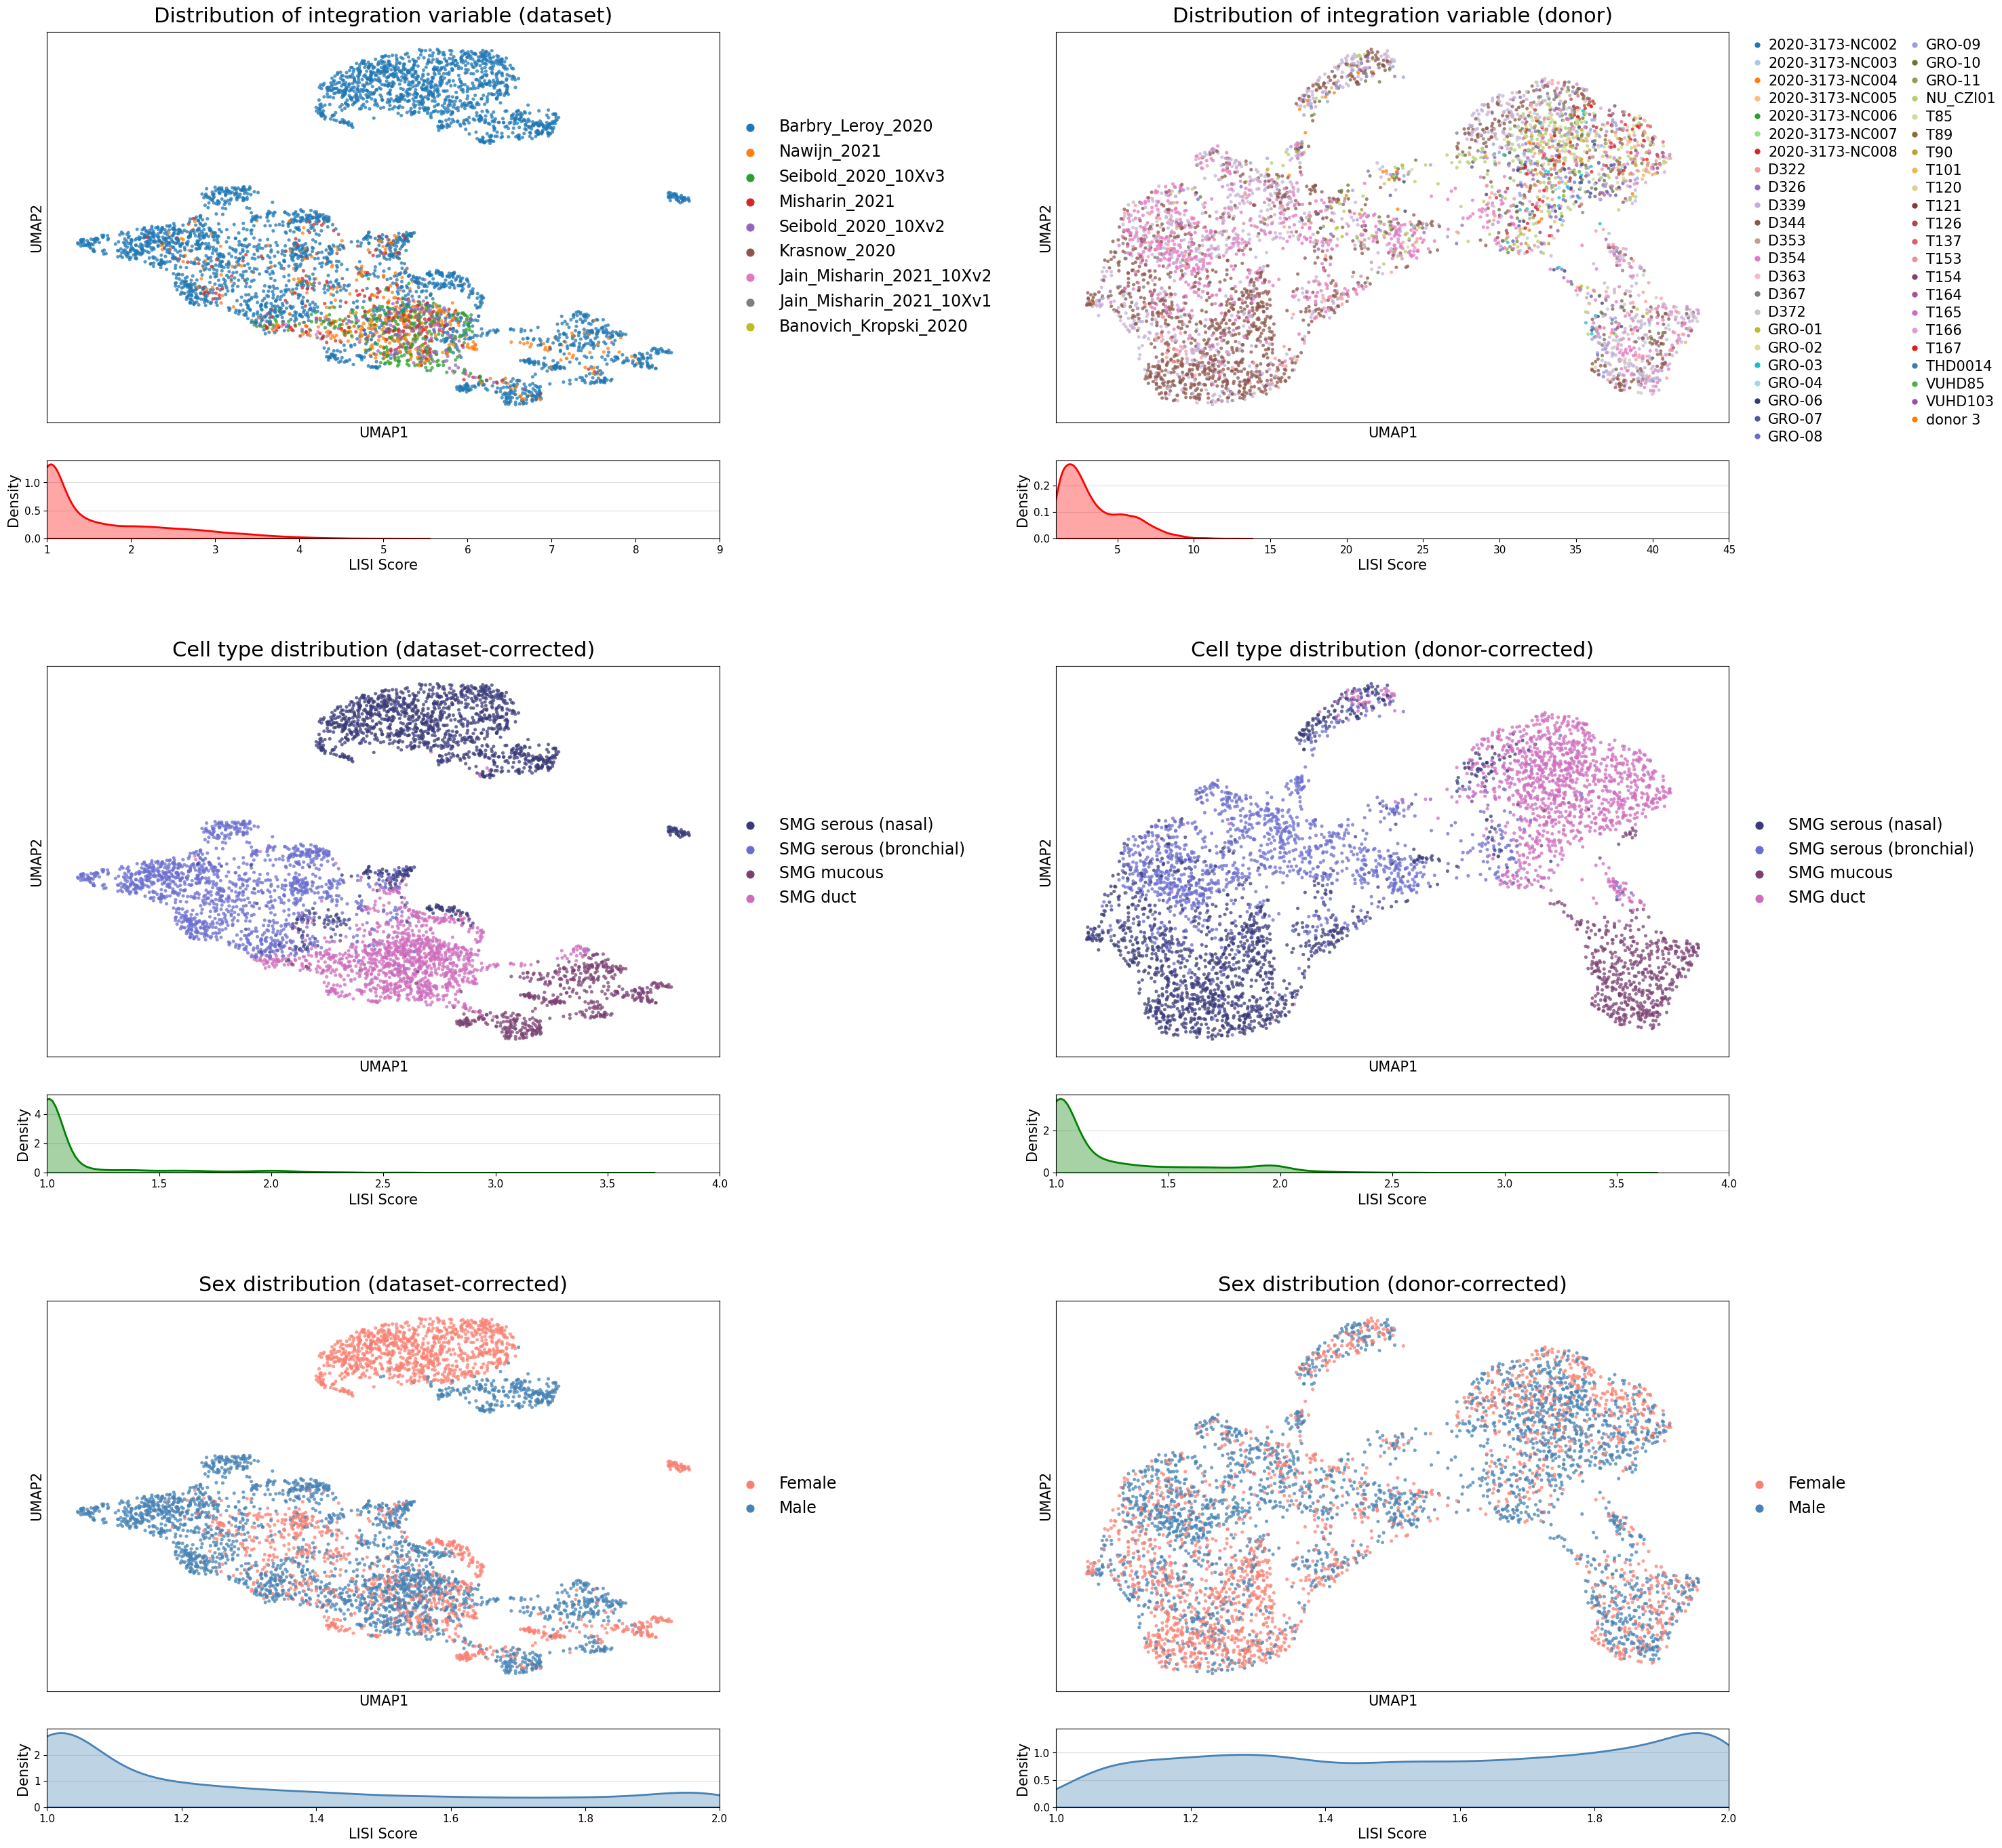

In [9]:
fig = plt.figure(figsize=(32, 34))

height_ratios = [3, 0.6, 0.4, 3, 0.6, 0.4, 3, 0.6]
gs = fig.add_gridspec(8, 2, height_ratios=height_ratios, hspace=0.2, wspace=0.5)

# label + palette prep
correction_labels = ['dataset-corrected', 'donor-corrected']
lisi_vars = {
    'dataset-corrected': ['LISI_dataset', 'LISI_ann_finest_level', 'LISI_sex'],
    'donor-corrected':   ['LISI_donor_id', 'LISI_ann_finest_level', 'LISI_sex'],
}
umap_vars_by_col = {
    'dataset-corrected': ['dataset',   'ann_finest_level', 'sex'],
    'donor-corrected':   ['donor_id',  'ann_finest_level', 'sex'],
}
titles_by_col = {
    'dataset-corrected': ['Distribution of integration variable (dataset)', 'Cell type distribution (dataset-corrected)', 'Sex distribution (dataset-corrected)'],
    'donor-corrected':   ['Distribution of integration variable (donor)',   'Cell type distribution (donor-corrected)',   'Sex distribution (donor-corrected)'],
}
palettes = {
    'dataset':          None, #scanpy default
    'donor_id':         donor_palette,
    'ann_finest_level': type_palette,
    'sex':              sex_color_map,
}
color_dict = {
    'LISI_dataset':           'red',
    'LISI_donor_id':          'red',
    'LISI_ann_finest_level':  'green',
    'LISI_sex':               'steelblue',
}
max_datasets = len(set(dataset_corr.obs["dataset"]))
max_celltypes = len(set(dataset_corr.obs["ann_finest_level"]))
max_donors = len(set(dataset_corr.obs["donor_id"]))
xlims = {
    'LISI_dataset': (1, max_datasets),
    'LISI_donor_id': (1, max_donors),
    'LISI_ann_finest_level': (1, max_celltypes),
    'LISI_sex': (1, 2),
}

# where results are stored
adatas = {
    'dataset-corrected': dataset_corr,
    'donor-corrected': donor_corr,
}
lisi_results = {
    'dataset-corrected': dataset_corr_results,
    'donor-corrected': donor_corr_results,
}
# shorten donor id
def shorten_donor_id(donor_id): 
    prefix = 'homosapiens_None_2023_None_sikkemalisa_001_d10_1101_2022_03_10_483747' 
    return donor_id.replace(prefix, '')
for adata in [dataset_corr, donor_corr]:
    adata.obs['donor_id'] = adata.obs['donor_id'].astype(str).apply(shorten_donor_id)

# sizes
TITLE_FS       = 22
LABEL_FS       = 15
TICK_FS        = 11
LEGEND_FS      = 17  
DONOR_LEGEND_FS = 15 
DOT_SIZE       = 55
def legend_fs_for(var):
    if var == 'donor_id':
        return DONOR_LEGEND_FS 
    return LEGEND_FS 
donor_umap_axes = {}
donor_lisi_axes = {} 

# plot
row_map = {
    0: (0, 1),
    1: (3, 4),
    2: (6, 7),
}
for col, corr in enumerate(correction_labels):
    for row_pair in range(3):
        umap_row, lisi_row = row_map[row_pair]
        var     = umap_vars_by_col[corr][row_pair]
        title   = titles_by_col[corr][row_pair]
        umap_ax = fig.add_subplot(gs[umap_row, col])
        lisi_ax = fig.add_subplot(gs[lisi_row, col])

        if palettes[var] is not None:
            palette_kwargs = {'palette': palettes[var]}
        else:
            palette_kwargs = {}

        # UMAP
        is_donor = (var == 'donor_id')
        sc.pl.umap(
            adatas[corr],
            color=var,
            ax=umap_ax,
            show=False,
            title='',
            legend_fontsize=legend_fs_for(var),
            legend_fontoutline=2,
            size=DOT_SIZE,
            alpha = 0.75,
            legend_loc='none' if is_donor else 'right margin', # custom legend for donor later
            **palette_kwargs,
        )
        umap_ax.set_title(title, fontsize=TITLE_FS, pad=10)
        umap_ax.set_xlabel('UMAP1', fontsize=LABEL_FS)
        umap_ax.set_ylabel('UMAP2', fontsize=LABEL_FS)
        umap_ax.tick_params(labelsize=TICK_FS)
        leg = umap_ax.get_legend()
        if leg is not None:
            leg.set_title('')    
            for lh in leg.legend_handles:
                lh.set_sizes([60]) 
                lh.set_alpha(1.0)

        if is_donor:
            donor_umap_axes[col] = umap_ax
            donor_lisi_axes[col] = lisi_ax

        # LISI
        lisi_var = lisi_vars[corr][row_pair]
        sns.kdeplot(
            data=lisi_results[corr],
            x=lisi_var,
            fill=True,
            ax=lisi_ax,
            color=color_dict[lisi_var],
            alpha = 0.35,
            linewidth = 2
        )
        lisi_ax.set_xlim(*xlims[lisi_var])
        lisi_ax.set_xlabel('LISI Score', fontsize=LABEL_FS)
        lisi_ax.set_ylabel('Density', fontsize=LABEL_FS)
        lisi_ax.set_title('')
        lisi_ax.tick_params(labelsize=TICK_FS)
        lisi_ax.yaxis.grid(True, color='#e0e0e0', linewidth=0.8, zorder=0)
        lisi_ax.set_axisbelow(True)

fig.canvas.draw() 

for col, corr in enumerate(correction_labels):
    if col not in donor_umap_axes: 
        continue
    umap_ax = donor_umap_axes[col]
    lisi_ax = donor_lisi_axes[col]
    adata   = adatas[corr]

    donor_ids = adata.obs['donor_id'].cat.categories
    colors = adata.uns['donor_id_colors']

    handles = [
        matplotlib.lines.Line2D(
            [0], [0],
            marker='o', color='none',
            markerfacecolor=c, markeredgewidth=0,
            markersize=6,
            label=d,
        )
        for d, c in zip(donor_ids, colors)
    ]

    renderer  = fig.canvas.get_renderer()
    umap_bbox = umap_ax.get_position() 
    lisi_bbox = lisi_ax.get_position()

    legend_x = umap_bbox.x1 + 0.007        
    legend_y_top = umap_bbox.y1  
    legend_y_bot = lisi_bbox.y0  

    leg = fig.legend(
        handles=handles,
        loc='upper left',
        bbox_to_anchor=(legend_x, legend_y_top),
        ncol=2,
        fontsize=DONOR_LEGEND_FS,
        frameon=False,
        handlelength=0.8,
        handletextpad=0.4,
        columnspacing=0.8,
        labelspacing=0.3,
        borderpad=0,
    )

plt.savefig(f'{path_results}/Batch_corr.png', dpi=300, bbox_inches='tight', facecolor = 'white')
plt.show()